# KKBOX Churn Prediction — Deep Learning Model Comparison

네 가지 딥러닝 모델을 **각자의 전처리·학습 방식 그대로 독립적으로 실행**하고, 마지막에 ROC-AUC를 기준으로 최고 모델을 선정합니다.

### 모델 구성
| No. | Model | Owner |
|---|---|---|
| 1 | Baseline MLP + EarlyStopping | Heeyoung |
| 2 | BatchNorm MLP + EarlyStopping | Sunah |
| 3 | Dropout MLP + EarlyStopping | Sohee |
| 4 | BatchNorm + Dropout MLP + EarlyStopping | Yongwoo |

> 각 모델은 독립 실험입니다. 전처리와 학습 설정을 공통화하지 않았으며, 각 원본 노트북의 방식을 유지합니다.
> 마지막 비교표는 각 원본 코드에서 산출되는 AUC를 모아 비교합니다.


## 실행 방법

1. 위에서부터 모델별 섹션을 순서대로 실행합니다.
2. 각 모델 섹션 마지막의 **결과 저장 셀**까지 실행합니다.
3. 마지막 **Final Model Comparison** 섹션을 실행하면 AUC 기준 최고 모델이 자동 선정됩니다.



---
# 1. Baseline MLP
**기본 MLP + EarlyStopping · Heeyoung**

아래 코드는 해당 팀원의 원본 노트북 흐름을 유지합니다.


# 딥러닝 - 기본 MLP + EarlyStopping (PyTorch)

담당: 문희영 (기본 MLP + EarlyStopping)
전처리는 `03_ml_heeyoung.ipynb`와 동일 (days_to_expire는 데이터 누수로 판단해 제외)
공통 규칙: 동일한 integrated_data.csv, 동일한 train/test 분할(test_size=0.2, stratify=y, random_state=42)
기록 항목: 학습 곡선, ROC-AUC, Recall, F1

> 수업에서 사용한 PyTorch 기준으로 구현하며, BatchNorm/Dropout 없이 기본 MLP + EarlyStopping만 적용합니다.


# 1. 데이터 로드

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/processed/integrated_data.csv")
print(df.shape)
df.head(10)

(100000, 22)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,...,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,14.0,22.0,female,7.0,20160119.0,14.0,0.0,1386.0,...,30.0,18.0,0.0,4.0,18397.448,68.0,78.0,11.0,1,1
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,1.0,0.0,NaN,7.0,20151027.0,17.0,0.0,1683.0,...,30.0,27.0,0.0,0.0,0.000,0.0,0.0,NaN,1,0
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,13.0,29.0,male,7.0,20140518.0,26.0,0.0,3754.0,...,30.0,17.0,0.0,55.0,134757.376,529.0,541.0,3.0,1,1
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,1.0,0.0,NaN,4.0,20161214.0,3.0,0.0,450.0,...,30.0,16.0,0.0,65.0,352944.005,1293.0,1312.0,0.0,1,1
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,1.0,0.0,NaN,7.0,20130915.0,20.0,0.0,1980.0,...,30.0,6.0,0.0,8.0,29785.691,106.0,121.0,0.0,1,1
5,lg3zG4deV9LDua90hgftaBHgV97OTYNl7iR0IbJDhFw=,0,15.0,29.0,female,9.0,20090718.0,20.0,0.0,2980.0,...,30.0,53.0,0.0,4.0,10133.685,32.0,27.0,75.0,1,1
6,ia7d0Dw3wYAP8evWEwftFCbw0dWoKkrxQ6BQvruSpcs=,0,13.0,34.0,NaN,9.0,20131023.0,22.0,0.0,3278.0,...,30.0,31.0,0.0,23.0,91863.181,324.0,333.0,9.0,1,1
7,Gh2S7y+rTVK3zHwqtGwnAUFxZ4QZo9JuEX01ykl7sDs=,0,1.0,0.0,NaN,7.0,20160122.0,14.0,0.0,1386.0,...,30.0,21.0,0.0,79.0,904878.545,3754.0,2485.0,0.0,1,1
8,j84nJ8grTvXdE3lBR4IZ7Yb3GXnFwD3WvaiZ5S/drfM=,0,11.0,0.0,NaN,3.0,20131217.0,27.0,3.0,3855.0,...,30.0,3.0,0.0,23.0,38083.585,157.0,125.0,0.0,1,1
9,iXWRSn+9nymKIpbu510N//m87vQcnCYUifuXn/GMqGk=,0,1.0,0.0,NaN,7.0,20160104.0,14.0,0.0,1386.0,...,30.0,3.0,0.0,0.0,0.000,0.0,0.0,NaN,1,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    100000 non-null  object 
 1   is_churn                100000 non-null  int64  
 2   city                    88648 non-null   float64
 3   bd                      88648 non-null   float64
 4   gender                  39831 non-null   object 
 5   registered_via          88648 non-null   float64
 6   registration_init_time  88648 non-null   float64
 7   transaction_count       100000 non-null  float64
 8   cancel_count            100000 non-null  float64
 9   total_payment           100000 non-null  float64
 10  last_auto_renew         99862 non-null   float64
 11  last_is_cancel          99862 non-null   float64
 12  last_plan_days          99862 non-null   float64
 13  days_to_expire          99862 non-null   float64
 14  cancel_on_last_date  

In [3]:
# 컬럼별 결측치 확인
df.isnull().sum()

msno                          0
is_churn                      0
city                      11352
bd                        11352
gender                    60169
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew             138
last_is_cancel              138
last_plan_days              138
days_to_expire              138
cancel_on_last_date         138
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log       18281
has_transaction               0
has_log                       0
dtype: int64

In [4]:
# 이탈 비율 확인 (원본과 일치하는지)
df['is_churn'].value_counts(normalize=True)

is_churn
0    0.91049
1    0.08951
Name: proportion, dtype: float64

In [5]:
# has_transaction / has_log 분포 확인 — 결측 처리 방향 결정에 참고
print(df['has_transaction'].value_counts())
print(df['has_log'].value_counts())

has_transaction
1    99862
0      138
Name: count, dtype: int64
has_log
1    81719
0    18281
Name: count, dtype: int64


# 2. 전처리 (03_ml_heeyoung.ipynb와 동일한 로직 사용)

### 2-1. 범주형 컬럼 확인

In [6]:
# city, registered_via는 숫자로 저장되어 있지만 실제로는 범주형 변수임
print(df['city'].nunique())
print(df['registered_via'].nunique())

21
5


### 2-2. gender 결측치 처리

In [7]:
# gender 결측치를 'Unknown' 카테고리로 채움
df['gender'] = df['gender'].fillna('Unknown')
df['gender'].value_counts()

gender
Unknown    60169
male       20923
female     18908
Name: count, dtype: int64

### 2-3. bd(나이) 이상치 처리

In [8]:
# EDA에서 확인된 기준: 10~80세만 정상, 그 외(0/음수/81세 이상)는 이상치
print(df['bd'].describe())

count    88648.000000
mean        13.497981
std         19.685454
min        -51.000000
25%          0.000000
50%          0.000000
75%         27.000000
max       1820.000000
Name: bd, dtype: float64


In [9]:
# EDA에서 확인된 기준: 10~80세만 정상, 그 외는 이상치로 처리
bd_valid = df['bd'].between(10, 80)

df['bd_is_missing'] = (~bd_valid).astype(int)
median_bd = df.loc[bd_valid, 'bd'].median()
df.loc[~bd_valid, 'bd'] = median_bd

print('중앙값 대체:', median_bd)
print(df['bd_is_missing'].value_counts(normalize=True))

중앙값 대체: 28.0
bd_is_missing
1    0.60424
0    0.39576
Name: proportion, dtype: float64


### 2-4. 거래/로그 없는 고객 처리 (has_transaction, has_log 활용)

In [10]:
# last_auto_renew, last_is_cancel 등은 거래 기록이 없으면(has_transaction=0) NaN
# -1로 채워서 "기록 없음"을 별도 값으로 표시 (0/1과 겹치지 않는 값)
df['last_auto_renew'] = df['last_auto_renew'].fillna(-1)
df['last_is_cancel'] = df['last_is_cancel'].fillna(-1)
df['last_plan_days'] = df['last_plan_days'].fillna(-1)
df['cancel_on_last_date'] = df['cancel_on_last_date'].fillna(-1)

# days_to_expire: '마지막 거래 만료일 - 기준일(2/28)' 파생 컬럼
# -> is_churn 그룹별 분포/음수비율 확인 + LightGBM feature importance 1위 + 제거 시 ROC-AUC 3.77%p 하락 확인됨
# -> 이탈 여부와 사실상 직결된 정보(정답 유출)로 판단해 모델링에서 완전히 제외함
df = df.drop(columns=['days_to_expire'])

# days_since_last_log: 로그가 없는 사람은 "아주 오랫동안 안 들었다"는 의미로 최댓값으로 채움
df['days_since_last_log'] = df['days_since_last_log'].fillna(df['days_since_last_log'].max())

# 처리 후 결측치 재확인
df.isnull().sum()

msno                          0
is_churn                      0
city                      11352
bd                            0
gender                        0
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew               0
last_is_cancel                0
last_plan_days                0
cancel_on_last_date           0
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log           0
has_transaction               0
has_log                       0
bd_is_missing                 0
dtype: int64

### 2-5. 범주형 컬럼 원-핫 인코딩

In [11]:
# city, registered_via 결측치를 별도 카테고리(-1)로 채움
df['city'] = df['city'].fillna(-1)
df['registered_via'] = df['registered_via'].fillna(-1)

df.isnull().sum()

msno                          0
is_churn                      0
city                          0
bd                            0
gender                        0
registered_via                0
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew               0
last_is_cancel                0
last_plan_days                0
cancel_on_last_date           0
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log           0
has_transaction               0
has_log                       0
bd_is_missing                 0
dtype: int64

In [12]:
# city, registered_via, gender 원-핫 인코딩
# drop_first=True: 다중공선성 방지를 위해 각 컬럼당 카테고리 1개는 기준값으로 제외
categorical_cols = ['gender', 'city', 'registered_via']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# registration_init_time은 문자열(날짜) 그대로 모델에 넣을 수 없으므로 제거
df_encoded = df_encoded.drop(columns=['registration_init_time'])

print(df_encoded.shape)
df_encoded.head()

(100000, 46)


,msno,is_churn,bd,transaction_count,cancel_count,total_payment,last_auto_renew,last_is_cancel,last_plan_days,cancel_on_last_date,...,city_18.0,city_19.0,city_20.0,city_21.0,city_22.0,registered_via_3.0,registered_via_4.0,registered_via_7.0,registered_via_9.0,registered_via_13.0
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,22.0,14.0,0.0,1386.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,28.0,17.0,0.0,1683.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,29.0,26.0,0.0,3754.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,28.0,3.0,0.0,450.0,0.0,0.0,30.0,0.0,...,False,False,False,False,False,False,True,False,False,False
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,28.0,20.0,0.0,1980.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False


# 3. train_test_split

MLP는 입력 스케일에 민감하므로, 트리 모델과 달리 **StandardScaler로 스케일링을 추가**합니다.
먼저 train/test를 공통 규칙으로 나눈 뒤, train을 다시 train/validation으로 분리합니다.
그 다음 **실제 학습용 train 데이터에만 StandardScaler를 fit**하고 validation/test에는 transform만 적용해 데이터 누수를 방지합니다.
최초 train/test 분할 파라미터(test_size, stratify, random_state)는 `03_ml_heeyoung.ipynb`와 동일하게 유지합니다.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X(피처)와 y(타겟) 분리
X = df_encoded.drop(columns=['msno', 'is_churn'])
y = df_encoded['is_churn']

# 1) 공통 규칙으로 train / test 분리
# test_size=0.2, stratify=y(클래스 비율 유지), random_state=42(재현성)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) train 내부에서 train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

# 3) scaler는 실제 학습용 train에만 fit
# validation / test는 같은 scaler로 transform만 수행
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("train :", X_train_scaled.shape)
print("val   :", X_val_scaled.shape)
print("test  :", X_test_scaled.shape)


train : (64000, 44)
val   : (16000, 44)
test  : (20000, 44)


# 4. 기본 MLP 모델 구성 + EarlyStopping

가장 단순한 구조(BatchNorm/Dropout 없음)의 MLP에 EarlyStopping만 적용한 베이스라인입니다.
다른 팀원들이 담당하는 BatchNorm / Dropout / BatchNorm+Dropout 버전과 비교할 기준선 역할을 합니다.

PyTorch에서는 `BCEWithLogitsLoss`를 사용하므로 마지막 층에 Sigmoid를 넣지 않고, 평가 시점에 `torch.sigmoid()`를 적용합니다.


In [14]:
import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# 위 3번 셀에서 이미 train / validation / test 분리와 스케일링 완료
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

# Tensor 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

# DataLoader
BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 기본 MLP: BatchNorm / Dropout 없음
class BaselineMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

n_features = X_train_scaled.shape[1]
model = BaselineMLP(n_features).to(device)

print(model)
print("학습 파라미터 수:", sum(p.numel() for p in model.parameters() if p.requires_grad))


device: cpu
BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
학습 파라미터 수: 5505


In [15]:
# 클래스 불균형 대응
# ML 노트북의 scale_pos_weight와 같은 취지로 양성 클래스에 더 큰 가중치 적용
# 실제 학습에 사용하는 y_train만 기준으로 계산
neg = (y_train_np == 0).sum()
pos = (y_train_np == 1).sum()
pos_weight_value = neg / pos

print("neg:", neg)
print("pos:", pos)
print("pos_weight:", pos_weight_value)

# BCEWithLogitsLoss의 pos_weight는 양성(이탈=1) 클래스에 적용됨
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


neg: 58271
pos: 5729
pos_weight: 10.171234072263921


In [16]:
from sklearn.metrics import roc_auc_score

EPOCHS = 100
PATIENCE = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": []
}

best_val_loss = float("inf")
best_model_state = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    # -------------------------
    # 1) Train
    # -------------------------
    model.train()

    train_loss_sum = 0.0
    train_probs = []
    train_targets = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits)
        train_probs.extend(probs.detach().cpu().numpy().ravel())
        train_targets.extend(yb.detach().cpu().numpy().ravel())

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_auc = roc_auc_score(train_targets, train_probs)

    # -------------------------
    # 2) Validation
    # -------------------------
    model.eval()

    val_loss_sum = 0.0
    val_probs = []
    val_targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy().ravel())
            val_targets.extend(yb.cpu().numpy().ravel())

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_auc = roc_auc_score(val_targets, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_auc={train_auc:.4f} | val_auc={val_auc:.4f}"
    )

    # -------------------------
    # 3) EarlyStopping
    # -------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        patience_count = 0
    else:
        patience_count += 1

        if patience_count >= PATIENCE:
            print(f"EarlyStopping: epoch {epoch}에서 학습 종료")
            break

# 가장 좋은 validation loss의 가중치 복원
model.load_state_dict(best_model_state)
model.to(device)

print("Best val_loss:", best_val_loss)


Epoch 001 | train_loss=0.9305 | val_loss=0.8657 | train_auc=0.8105 | val_auc=0.8361
Epoch 002 | train_loss=0.8583 | val_loss=0.8592 | train_auc=0.8342 | val_auc=0.8374
Epoch 003 | train_loss=0.8521 | val_loss=0.8567 | train_auc=0.8390 | val_auc=0.8393
Epoch 004 | train_loss=0.8476 | val_loss=0.8507 | train_auc=0.8418 | val_auc=0.8432
Epoch 005 | train_loss=0.8445 | val_loss=0.8564 | train_auc=0.8434 | val_auc=0.8396
Epoch 006 | train_loss=0.8414 | val_loss=0.8519 | train_auc=0.8453 | val_auc=0.8412
Epoch 007 | train_loss=0.8364 | val_loss=0.8521 | train_auc=0.8480 | val_auc=0.8400
Epoch 008 | train_loss=0.8349 | val_loss=0.8595 | train_auc=0.8486 | val_auc=0.8372
Epoch 009 | train_loss=0.8328 | val_loss=0.8519 | train_auc=0.8494 | val_auc=0.8405
EarlyStopping: epoch 9에서 학습 종료
Best val_loss: 0.8507054076194763


# 5. 학습 곡선 (Loss / AUC)

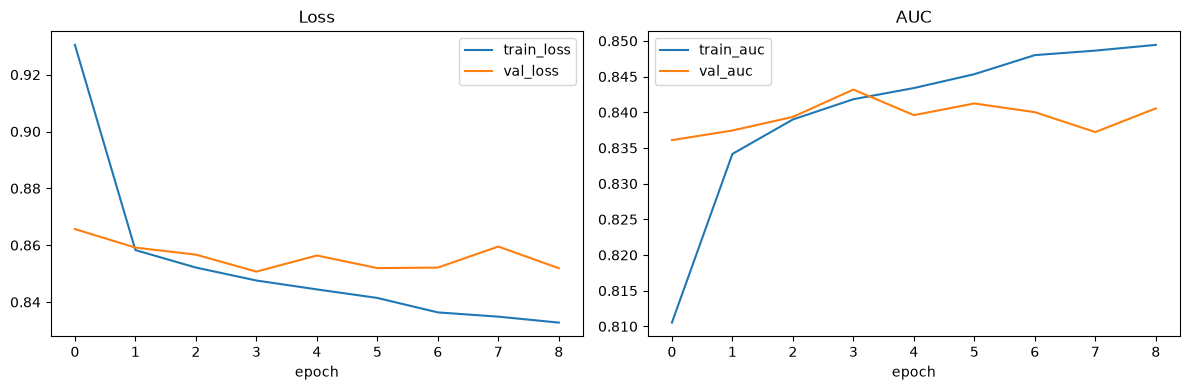

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train_auc")
axes[1].plot(history["val_auc"], label="val_auc")
axes[1].set_title("AUC")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


# 6. 평가 (ROC-AUC, Recall, F1)

In [18]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

test_probs = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        test_probs.extend(probs.cpu().numpy().ravel())
        test_targets.extend(yb.numpy().ravel())

y_pred_proba = np.array(test_probs)
y_test_eval = np.array(test_targets).astype(int)

# 팀 공통 기준: threshold=0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test_eval, y_pred_proba)
recall = recall_score(y_test_eval, y_pred)
f1 = f1_score(y_test_eval, y_pred)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1     : {f1:.4f}")
print()
print(classification_report(y_test_eval, y_pred))
print(confusion_matrix(y_test_eval, y_pred))


ROC-AUC: 0.8338
Recall : 0.6592
F1     : 0.5087

              precision    recall  f1-score   support

           0       0.96      0.91      0.94     18210
           1       0.41      0.66      0.51      1790

    accuracy                           0.89     20000
   macro avg       0.69      0.78      0.72     20000
weighted avg       0.92      0.89      0.90     20000

[[16541  1669]
 [  610  1180]]


# 7. 결과 요약

### 최종 성능
- ROC-AUC: **0.8338**
- Recall: **0.6592**
- F1-score: **0.5087**
- EarlyStopping: **9 epoch에서 학습 종료**
- Best validation loss: **0.8507**

### 참고
- 프레임워크: PyTorch
- 전처리는 `03_ml_heeyoung.ipynb`와 동일 (`days_to_expire` 제외)
- train/test 분할 후 train을 다시 train/validation으로 분리
- `StandardScaler`는 실제 학습용 train에만 fit, validation/test에는 transform만 적용
- 기본 MLP 구조: **64 → 32 → 16 → 1** (BatchNorm / Dropout 없음)
- 클래스 불균형 대응: `BCEWithLogitsLoss(pos_weight=neg/pos)`
- EarlyStopping: `val_loss` 기준, `patience=5`, best weight 복원
- 평가 threshold: **0.5**
- 위 결과와 학습 곡선을 `05_dl_comparison.ipynb` 취합 시 사용


### 1. Baseline MLP — Result Snapshot
최종 비교를 위해 이 모델의 평가 결과를 고유 변수에 저장합니다.


In [19]:
# 모델 1 결과 저장 (다른 모델 실행 시 변수명이 덮어써지는 것을 방지)
baseline_result = {
    "Model": "Baseline MLP + EarlyStopping",
    "Owner": "Heeyoung",
    "Evaluation Set": "Test",
    "AUC": float(roc_auc),
    "Recall": float(recall),
    "F1": float(f1)
}
display(pd.DataFrame([baseline_result]).round(4))


,Model,Owner,Evaluation Set,AUC,Recall,F1
0,Baseline MLP + EarlyStopping,Heeyoung,Test,0.8338,0.6592,0.5087



---
# 2. BatchNorm MLP
**BatchNorm MLP + EarlyStopping · Sunah**

아래 코드는 해당 팀원의 원본 노트북 흐름을 유지합니다.


# KKBOX Churn Prediction — Base Preprocessing Notebook

이 노트북은 **모델링 이전의 공통 전처리 과정**만 포함합니다.

포함 범위:
- 데이터 로드
- Target 확인
- 기본 변수 정리
- Train / Test Split
- 결측치 처리 및 불필요 변수 제거
- Feature Engineering
- 파생변수 생성 결과 점검

> 이 노트북 이후부터 ML / DL 모델별 전처리 및 모델링을 별도로 진행합니다.


## 1. Library & Data Load


In [20]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42


In [21]:
# 내 PC에서 사용하는 실제 데이터 경로
DATA_PATH = Path(
    r"C:\dev\project\2차 단위 프로젝트\2nd-dev\data\processed\integrated_data.csv"
)

# 다른 팀원이 저장소를 clone한 경우를 위한 상대경로 fallback
if not DATA_PATH.exists():
    DATA_PATH = Path("data/processed/integrated_data.csv")

print("Data path:", DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
display(df.head())


Data path: C:\dev\project\2차 단위 프로젝트\2nd-dev\data\processed\integrated_data.csv
shape: (100000, 22)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,...,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,14.0,22.0,female,7.0,20160119.0,14.0,0.0,1386.0,...,30.0,18.0,0.0,4.0,18397.448,68.0,78.0,11.0,1,1
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,1.0,0.0,NaN,7.0,20151027.0,17.0,0.0,1683.0,...,30.0,27.0,0.0,0.0,0.000,0.0,0.0,NaN,1,0
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,13.0,29.0,male,7.0,20140518.0,26.0,0.0,3754.0,...,30.0,17.0,0.0,55.0,134757.376,529.0,541.0,3.0,1,1
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,1.0,0.0,NaN,4.0,20161214.0,3.0,0.0,450.0,...,30.0,16.0,0.0,65.0,352944.005,1293.0,1312.0,0.0,1,1
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,1.0,0.0,NaN,7.0,20130915.0,20.0,0.0,1980.0,...,30.0,6.0,0.0,8.0,29785.691,106.0,121.0,0.0,1,1


## 2. Target 확인

In [22]:
print("Target count")
display(df["is_churn"].value_counts().sort_index().to_frame())

print("Target ratio")
display(df["is_churn"].value_counts(normalize=True).sort_index().to_frame())


Target count


,count
is_churn,
0,91049
1,8951


Target ratio


,proportion
is_churn,
0,0.91049
1,0.08951


## 3. Split 이전 기본 정리

기존 모델 비교 노트북의 기준을 그대로 사용합니다.

- `bd`: 10~80세만 정상값으로 처리
- 정상 범위를 벗어난 나이는 결측 처리 후 `age_group='unknown'`
- `gender` 결측치는 `Unknown`
- `registration_init_time`은 날짜형으로 변환하되 모델 입력에서는 제외


In [23]:
df["registration_init_time"] = pd.to_datetime(
    df["registration_init_time"],
    format="%Y%m%d",
    errors="coerce"
)

df.loc[~df["bd"].between(10, 80), "bd"] = np.nan

df["age_group"] = pd.cut(
    df["bd"],
    bins=[9, 19, 29, 39, 49, 59, 69, 80],
    labels=["10s", "20s", "30s", "40s", "50s", "60s", "70_80"]
)

df["age_group"] = (
    df["age_group"]
    .cat.add_categories("unknown")
    .fillna("unknown")
)

df["gender"] = df["gender"].fillna("Unknown")


## 4. Train / Test Split

In [24]:
X = df.drop(columns="is_churn")
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print(f"Train churn ratio: {y_train.mean():.4f}")
print(f"Test churn ratio : {y_test.mean():.4f}")


X_train: (80000, 22)
X_test : (20000, 22)
Train churn ratio: 0.0895
Test churn ratio : 0.0895


## 5. 결측치 처리 및 불필요 변수 제거

Train 데이터에서 계산한 값만 이용해 Test 데이터를 처리하여 데이터 누수를 방지합니다.

- `city`: 제외
- `registered_via`: Train 최빈값
- `last_auto_renew`, `last_is_cancel`, `last_plan_days`: Train 최빈값
- `days_since_last_log`: Train 평균
- `registration_init_time`, `cancel_on_last_date`, `days_to_expire`, `bd`: 모델 입력에서 제외


In [25]:
X_train = X_train.drop(columns=["city"])
X_test = X_test.drop(columns=["city"])

registered_via_mode = X_train["registered_via"].mode()[0]
X_train["registered_via"] = X_train["registered_via"].fillna(registered_via_mode)
X_test["registered_via"] = X_test["registered_via"].fillna(registered_via_mode)

for col in ["last_auto_renew", "last_is_cancel", "last_plan_days"]:
    fill_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(fill_value)
    X_test[col] = X_test[col].fillna(fill_value)

last_log_mean = X_train["days_since_last_log"].mean()
X_train["days_since_last_log"] = X_train["days_since_last_log"].fillna(last_log_mean)
X_test["days_since_last_log"] = X_test["days_since_last_log"].fillna(last_log_mean)

drop_cols = [
    "registration_init_time",
    "cancel_on_last_date",
    "days_to_expire",
    "bd"
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("Remaining nulls before feature engineering")
display(
    pd.DataFrame({
        "train_null": X_train.isna().sum(),
        "test_null": X_test.isna().sum()
    }).query("train_null > 0 or test_null > 0")
)


Remaining nulls before feature engineering


,train_null,test_null


## 6. Feature Engineering

나눗셈으로 만드는 파생변수는 **safe division**을 사용합니다.

- 분모가 0이면 해당 파생값을 `0`으로 처리
- `inf`, `-inf`가 생성되는 것을 방지
- 이후 DL 전처리 직전 숫자형 변수의 남은 `NaN / inf`도 한 번 더 정리


In [26]:
def safe_divide(numerator, denominator):
    """분모가 0이면 0을 반환하는 안전한 나눗셈 함수"""
    num = numerator.to_numpy(dtype=float)
    den = denominator.to_numpy(dtype=float)

    result = np.zeros(len(numerator), dtype=float)
    np.divide(
        num,
        den,
        out=result,
        where=(den != 0)
    )

    return pd.Series(result, index=numerator.index)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    # 거래 관련
    data["cancel_rate"] = safe_divide(
        data["cancel_count"],
        data["transaction_count"]
    )

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


X_train = add_features(X_train)
X_test = add_features(X_test)


In [27]:
new_features = [
    "cancel_rate",
    "avg_payment",
    "avg_daily_secs",
    "avg_daily_complete",
    "avg_daily_unq",
    "complete_per_unq",
    "payment_per_plan_day"
]

display(X_train[new_features].describe().T)

print("Remaining NaN after safe division")
display(
    pd.DataFrame({
        "train_null": X_train[new_features].isna().sum(),
        "test_null": X_test[new_features].isna().sum()
    })
)

numeric_cols = X_train.select_dtypes(include=np.number).columns

print("Train inf count:", np.isinf(X_train[numeric_cols]).sum().sum())
print("Test inf count :", np.isinf(X_test[numeric_cols]).sum().sum())


,count,mean,std,min,25%,50%,75%,max
cancel_rate,80000.0,0.013980,0.036029,0.0,0.000000,0.000000,0.000000,0.500000
avg_payment,80000.0,148.039732,147.688809,0.0,99.000000,135.703704,149.000000,1788.000000
avg_daily_secs,80000.0,5372.417511,5909.252106,0.0,1763.491639,4161.423573,6973.038357,86400.000000
avg_daily_complete,80000.0,20.393373,24.618322,0.0,5.625000,15.193789,26.237500,1010.282353
avg_daily_unq,80000.0,20.428415,19.535412,0.0,7.571429,17.222222,27.780678,404.000000
complete_per_unq,80000.0,0.839236,1.182241,0.0,0.483862,0.842781,1.043478,141.000000
payment_per_plan_day,80000.0,4.419292,4.061066,0.0,3.300000,4.466667,4.966667,894.000000


Remaining NaN after safe division


,train_null,test_null
cancel_rate,0,0
avg_payment,0,0
avg_daily_secs,0,0
avg_daily_complete,0,0
avg_daily_unq,0,0
complete_per_unq,0,0
payment_per_plan_day,0,0


Train inf count: 0
Test inf count : 0


In [28]:
X_train.columns

Index(['msno', 'gender', 'registered_via', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
       'days_since_last_log', 'has_transaction', 'has_log', 'age_group',
       'no_unique_song', 'zero_plan_days', 'cancel_rate', 'avg_payment',
       'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
       'complete_per_unq', 'payment_per_plan_day'],
      dtype='object')

## 7. Base Preprocessing 완료

여기까지가 모든 모델에서 공통으로 사용할 **base preprocessing + feature engineering** 단계입니다.

현재 준비된 객체:
- `X_train`, `X_test`
- `y_train`, `y_test`

다음 단계부터는 모델별로 분기합니다.

예를 들어 DL 모델링에서는 이후에 다음 작업을 직접 진행할 수 있습니다.

1. `msno` 제거
2. 범주형 변수 인코딩
3. 수치형 변수 Scaling
4. Train / Validation 분리
5. Tensor / DataLoader 생성
6. MLP 모델 정의 및 학습



In [29]:
# msno는 단순 식별자이므로 drop하고 MLP용 데이터셋 생성
X_train_mlp = X_train.drop(columns=["msno"]).copy()
X_test_mlp = X_test.drop(columns=["msno"]).copy()

# PyTorch MLP는 NaN / inf를 직접 처리하지 못하므로 숫자형 변수만 최종 정리
numeric_mlp_cols = X_train_mlp.select_dtypes(include=np.number).columns

X_train_mlp[numeric_mlp_cols] = (
    X_train_mlp[numeric_mlp_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_test_mlp[numeric_mlp_cols] = (
    X_test_mlp[numeric_mlp_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("MLP train numeric NaN:", X_train_mlp[numeric_mlp_cols].isna().sum().sum())
print("MLP test numeric NaN :", X_test_mlp[numeric_mlp_cols].isna().sum().sum())
print("MLP train numeric inf:", np.isinf(X_train_mlp[numeric_mlp_cols]).sum().sum())
print("MLP test numeric inf :", np.isinf(X_test_mlp[numeric_mlp_cols]).sum().sum())


MLP train numeric NaN: 0
MLP test numeric NaN : 0
MLP train numeric inf: 0
MLP test numeric inf : 0


In [30]:
# train, validation 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_mlp,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [31]:
# 범주형 변수 인코딩 - One Hot Encoding
X_train_mlp.columns

Index(['gender', 'registered_via', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
       'days_since_last_log', 'has_transaction', 'has_log', 'age_group',
       'no_unique_song', 'zero_plan_days', 'cancel_rate', 'avg_payment',
       'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
       'complete_per_unq', 'payment_per_plan_day'],
      dtype='object')

In [32]:
# cat col: gender, registered_via, age_group
# last_auto_renew, last_is_cancel, has_transaction, has_log, zero_plan_days

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = [
    "gender",
    "registered_via",
    "age_group"
]

binary_cols = [
    'last_auto_renew',
    'last_is_cancel',
    'has_transaction',
    'has_log',
    'zero_plan_days'
]

num_cols = [
    col for col in X_train_mlp.columns
    if col not in cat_cols + binary_cols
]



In [33]:
# One Hot Encoding + Scaling

# 수치형 변수: StandardScaler
# 범주형 변수: OneHotEncoder
# 0/1 이진 변수: 그대로 통과(passthrough)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)


In [34]:
# 전처리 진행

X_tr = preprocessor.fit_transform(X_tr)
X_val = preprocessor.transform(X_val)
X_test_mlp = preprocessor.transform(X_test_mlp)

In [35]:
type(X_tr)

numpy.ndarray

In [36]:
# 이제 딥러닝 모델링을 위해 torch로 변환
import torch

X_tr_tensor = torch.tensor(X_tr, dtype = torch.float32)
X_val_tensor = torch.tensor(X_val, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_mlp, dtype = torch.float32)

y_tr_tensor = torch.tensor(
    y_tr.values,
    dtype=torch.float32
).reshape(-1, 1) #column 차원 1로 맞춰줌

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

In [37]:
# 먼저 X와 y를 묶어 TensorDataset으로 변환
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_tr_tensor, y_tr_tensor
)

val_dataset = TensorDataset(
    X_val_tensor, y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor, y_test_tensor
)

In [38]:
X_tr_tensor.shape

torch.Size([64000, 38])

In [39]:
# DataLoader 생성 -> batch로 쪼개준다.
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size = 256,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 256,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 256,
    shuffle = False
)

In [40]:
# MLP (다층 퍼셉트론: Multi-Layer-Perceptron) 모델 정의
import torch.nn as nn

class BatchNormMLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),

        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),

        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),

        nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.model(x)

In [41]:
# 모델 생성
input_dim = X_tr_tensor.shape[1]
model = BatchNormMLP(input_dim)

In [42]:
# Loss, Optimizer 정의

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [43]:
# EarlyStopper 정의
class EarlyStopper:
    def __init__(self, patience=5, path='best_model.pth'):
        self.patience = patience
        self.path = path

        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        # validation loss가 개선된 경우
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

            # 현재까지 가장 좋은 모델 저장
            torch.save(model.state_dict(), self.path)

        # validation loss가 개선되지 않은 경우
        else:
            self.counter += 1
            print(
                f"EarlyStopping counter: {self.counter} / {self.patience}"
            )

            if self.counter >= self.patience:
                self.early_stop = True


In [44]:
# EarlyStopper 객체 생성
early_stopper = EarlyStopper(
    patience = 5,
    path = 'best_batchnorm_mlp.pth'
)

In [45]:
# 학습
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ================= Train =================
    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # ================= Validation =================
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    # 학습 곡선용 기록
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


    # Early Stopping
    early_stopper(val_loss, model)

    if early_stopper.early_stop:
        print("Early Stopping!")
        break

Epoch 1/100 | Train Loss: 0.2805 | Val Loss: 0.2073
Epoch 2/100 | Train Loss: 0.2033 | Val Loss: 0.2029
Epoch 3/100 | Train Loss: 0.2003 | Val Loss: 0.2009
Epoch 4/100 | Train Loss: 0.1981 | Val Loss: 0.2015
EarlyStopping counter: 1 / 5
Epoch 5/100 | Train Loss: 0.1973 | Val Loss: 0.2014
EarlyStopping counter: 2 / 5
Epoch 6/100 | Train Loss: 0.1969 | Val Loss: 0.2025
EarlyStopping counter: 3 / 5
Epoch 7/100 | Train Loss: 0.1954 | Val Loss: 0.2009
Epoch 8/100 | Train Loss: 0.1948 | Val Loss: 0.1996
Epoch 9/100 | Train Loss: 0.1939 | Val Loss: 0.2064
EarlyStopping counter: 1 / 5
Epoch 10/100 | Train Loss: 0.1929 | Val Loss: 0.2004
EarlyStopping counter: 2 / 5
Epoch 11/100 | Train Loss: 0.1920 | Val Loss: 0.2011
EarlyStopping counter: 3 / 5
Epoch 12/100 | Train Loss: 0.1920 | Val Loss: 0.2004
EarlyStopping counter: 4 / 5
Epoch 13/100 | Train Loss: 0.1911 | Val Loss: 0.2024
EarlyStopping counter: 5 / 5
Early Stopping!


### Best model 불러오기

`best_batchnorm_mlp.pth` 파일은 미리 만들어두는 파일이 아니라, 위 학습 루프에서 `EarlyStopper`가 validation loss가 개선될 때 자동으로 저장합니다. 따라서 학습 셀을 먼저 실행한 뒤 아래 셀을 실행해야 합니다.


In [46]:
# 학습이 끝난 뒤 가장 성능이 좋았던 모델 불러오기
import os

model_path = "best_batchnorm_mlp.pth"

if os.path.exists(model_path):
    model.load_state_dict(
        torch.load(
            model_path,
            weights_only=True
        )
    )
    print("Best model loaded!")
else:
    print("저장된 모델 파일이 없습니다. 먼저 위의 학습 셀을 실행해주세요.")


Best model loaded!


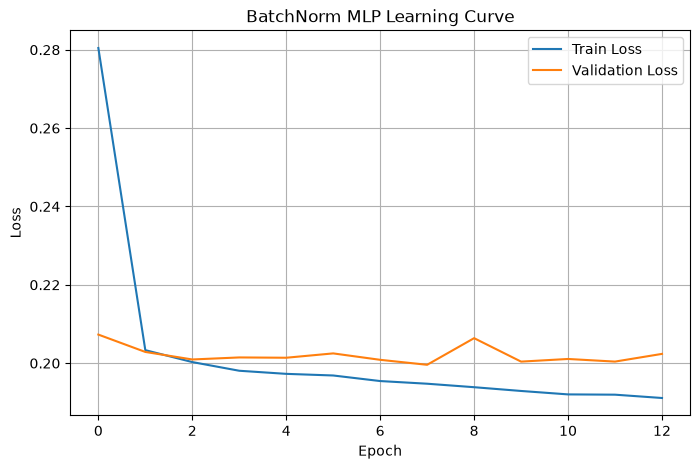

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BatchNorm MLP Learning Curve")

plt.legend()
plt.grid()

plt.show()

In [48]:
# Test Data 예측
model.eval()

y_true = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)

        # BCEWithLogitsLoss를 사용했으므로 sigmoid로 확률 변환
        probabilities = torch.sigmoid(outputs)

        y_true.extend(y_batch.cpu().numpy().flatten())
        y_prob.extend(probabilities.cpu().numpy().flatten())


## 8. Test Evaluation

최종 저장된 **BatchNorm MLP + EarlyStopping** 모델을 Test set으로 평가합니다.

- **AUC**: 예측 확률의 순위 판별 성능
- **Recall**: 실제 이탈 고객 중 모델이 이탈로 찾아낸 비율
- **F1**: Precision과 Recall의 조화평균


In [49]:
# 확률 -> 0/1 예측값 변환
import numpy as np

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# 기본 threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)


In [50]:
# AUC / Recall / F1 계산
from sklearn.metrics import roc_auc_score, recall_score, f1_score

auc = roc_auc_score(y_true, y_prob)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"AUC    : {auc:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1     : {f1:.4f}")


AUC    : 0.8458
Recall : 0.3849
F1     : 0.5157


In [51]:
# 팀 모델 비교용 결과 표
result = pd.DataFrame({
    "Model": ["BatchNorm MLP + EarlyStopping"],
    "AUC": [auc],
    "Recall": [recall],
    "F1": [f1]
})

display(result.round(4))


,Model,AUC,Recall,F1
0,BatchNorm MLP + EarlyStopping,0.8458,0.3849,0.5157


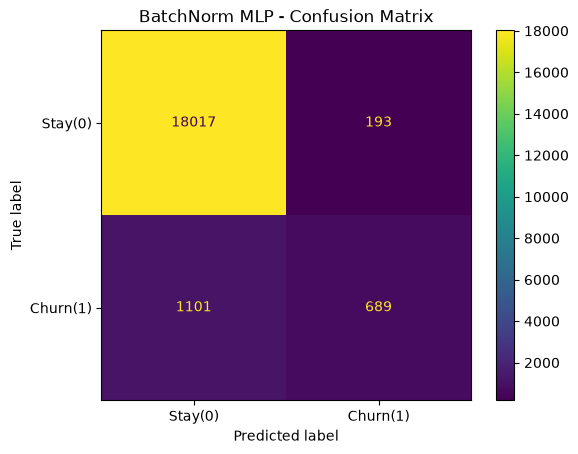

In [52]:
# Confusion Matrix (추가 확인용)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay(0)", "Churn(1)"])
disp.plot()
plt.title("BatchNorm MLP - Confusion Matrix")
plt.show()


### 최종 기록 항목

이 노트북에서 팀 요구사항인 다음 항목을 확인할 수 있습니다.

1. Train / Validation **학습 곡선**
2. Test **AUC**
3. Test **Recall**
4. Test **F1**

> 다른 팀원의 Dropout 또는 BatchNorm+Dropout 구조는 추가하지 않았습니다.


### 2. BatchNorm MLP — Result Snapshot
최종 비교를 위해 이 모델의 평가 결과를 고유 변수에 저장합니다.


In [53]:
# 모델 2 결과 저장
batchnorm_result = {
    "Model": "BatchNorm MLP + EarlyStopping",
    "Owner": "Sunah",
    "Evaluation Set": "Test",
    "AUC": float(auc),
    "Recall": float(recall),
    "F1": float(f1)
}
display(pd.DataFrame([batchnorm_result]).round(4))


,Model,Owner,Evaluation Set,AUC,Recall,F1
0,BatchNorm MLP + EarlyStopping,Sunah,Test,0.8458,0.3849,0.5157



---
# 3. Dropout MLP
**Dropout MLP + EarlyStopping · Sohee**

아래 코드는 해당 팀원의 원본 노트북 흐름을 유지합니다.


# Deep_Learning

---

## Load Dataset

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [55]:
data = pd.read_csv("../../data/processed/integrated_data.csv")
data.head()

print(data.shape)

(100000, 22)


## Target

In [56]:
target = "is_churn"

print(data[target].value_counts())
print(data[target].value_counts(normalize=True))

is_churn
0    91049
1     8951
Name: count, dtype: int64
is_churn
0    0.91049
1    0.08951
Name: proportion, dtype: float64


In [57]:
data.isna().sum()

msno                          0
is_churn                      0
city                      11352
bd                        11352
gender                    60169
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew             138
last_is_cancel              138
last_plan_days              138
days_to_expire              138
cancel_on_last_date         138
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log       18281
has_transaction               0
has_log                       0
dtype: int64

## 평가 & 학습 데이터셋

In [58]:
# 8:2 분할
from sklearn.model_selection import train_test_split

train, valid = train_test_split(
    data,
    test_size=0.2,
    stratify=data[target],
    random_state=42
)

train = train.copy()
valid = valid.copy()

train.shape, valid.shape

((80000, 22), (20000, 22))

# EDA

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    100000 non-null  object 
 1   is_churn                100000 non-null  int64  
 2   city                    88648 non-null   float64
 3   bd                      88648 non-null   float64
 4   gender                  39831 non-null   object 
 5   registered_via          88648 non-null   float64
 6   registration_init_time  88648 non-null   float64
 7   transaction_count       100000 non-null  float64
 8   cancel_count            100000 non-null  float64
 9   total_payment           100000 non-null  float64
 10  last_auto_renew         99862 non-null   float64
 11  last_is_cancel          99862 non-null   float64
 12  last_plan_days          99862 non-null   float64
 13  days_to_expire          99862 non-null   float64
 14  cancel_on_last_date  

In [60]:
# 컬럼별 결측치 개수와 비율 확인
null_ratio = train.isnull().mean()

pd.DataFrame({"결측치 비율": null_ratio}).sort_values("결측치 비율", ascending=False)

,결측치 비율
gender,0.602125
days_since_last_log,0.183138
bd,0.113113
registered_via,0.113113
registration_init_time,0.113113
city,0.113113
days_to_expire,0.001350
last_auto_renew,0.001350
last_is_cancel,0.001350
last_plan_days,0.001350


In [61]:
train.describe()

,is_churn,city,bd,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
count,80000.000000,70951.000000,70951.000000,70951.000000,7.095100e+04,80000.000000,80000.000000,80000.000000,79892.000000,79892.000000,79892.000000,79892.000000,79892.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,65349.000000,80000.000000,80000.000000
mean,0.089512,5.909008,13.503249,6.897140,2.013251e+07,15.773450,0.258663,2126.222500,0.881578,0.009701,35.181457,19.078631,0.017611,38.901863,3.077090e+05,1176.734175,1136.247537,4.373609,0.998650,0.816863
std,0.285484,6.428790,20.456424,1.934361,3.019727e+04,8.683796,0.564522,1258.497806,0.323110,0.098013,38.810508,26.764915,0.131535,31.051256,4.602965e+05,1888.534219,1519.355226,11.719927,0.036718,0.386782
min,0.000000,1.000000,-51.000000,3.000000,2.004033e+07,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-1156.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,7.000000,2.012021e+07,8.000000,0.000000,1043.000000,1.000000,0.000000,30.000000,9.000000,0.000000,6.000000,1.559313e+04,51.000000,70.000000,0.000000,1.000000,1.000000
50%,0.000000,1.000000,0.000000,7.000000,2.014052e+07,16.000000,0.000000,1881.000000,1.000000,0.000000,30.000000,18.000000,0.000000,38.000000,1.576764e+05,574.000000,635.000000,0.000000,1.000000,1.000000
75%,0.000000,13.000000,27.000000,9.000000,2.016012e+07,23.000000,0.000000,3278.000000,1.000000,0.000000,30.000000,26.000000,0.000000,68.000000,4.059961e+05,1515.000000,1592.000000,3.000000,1.000000,1.000000
max,1.000000,22.000000,1820.000000,13.000000,2.017023e+07,59.000000,11.000000,7450.000000,1.000000,1.000000,450.000000,892.000000,1.000000,90.000000,7.622046e+06,85874.000000,27088.000000,89.000000,1.000000,1.000000


In [62]:
# 두 집단의 최근 이용 활동 중앙값 비교
log_cols = ["activity_days", "total_secs", "total_num_100", "total_num_unq"]
display(train.groupby(target)[log_cols].median().T)

is_churn,0,1
activity_days,37.000,39.000
total_secs,155543.692,179283.702
total_num_100,566.000,661.000
total_num_unq,626.000,738.000


In [63]:
# 자동 갱신 여부별 고객 수와 이탈률 비교
summary = train.groupby("last_auto_renew", dropna=False)[target].agg(
    customers="size", churn_rate="mean"
)
display(summary)

,customers,churn_rate
last_auto_renew,,
0.0,9461,0.412113
1.0,70431,0.045307
NaN,108,0.657407


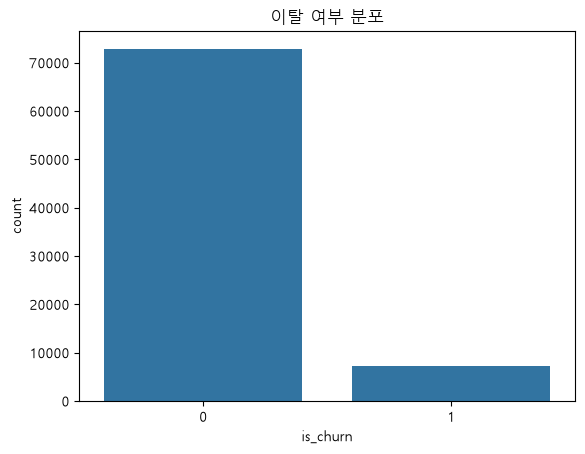

In [64]:
# 타깃 분포
sns.countplot(data=train, x="is_churn")
plt.title("이탈 여부 분포")
plt.show()

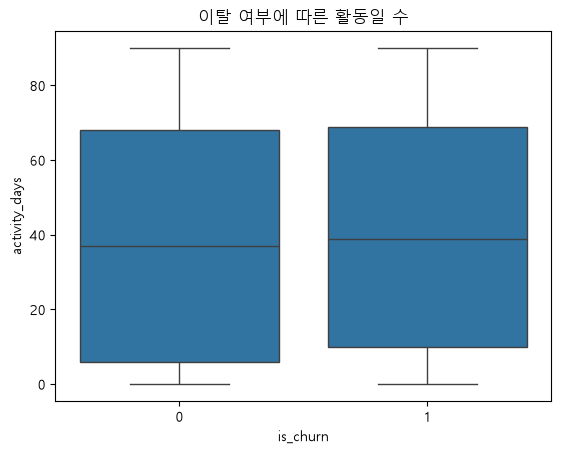

In [65]:
# 활동일 수 비교
sns.boxplot(data=train, x="is_churn", y="activity_days")
plt.title("이탈 여부에 따른 활동일 수")
plt.show()

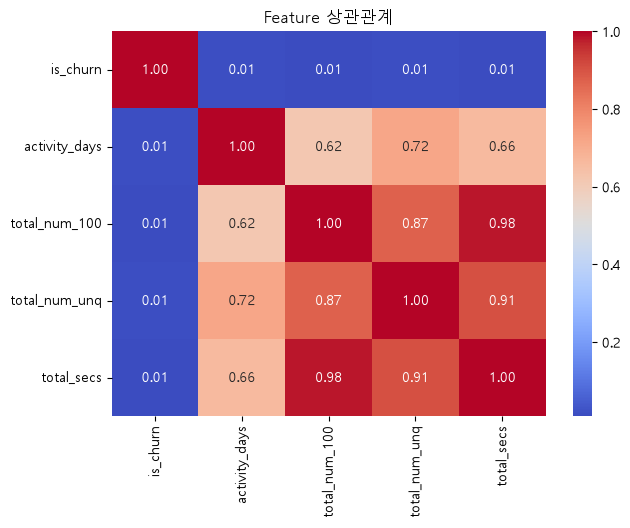

In [66]:
# 피처 상관관계
corr_cols = [
    "is_churn",
    "activity_days",
    "total_num_100",
    "total_num_unq",
    "total_secs"
]

plt.figure(figsize=(7, 5))

sns.heatmap(
    train[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature 상관관계")
plt.show()

# Feature Engineering

## user_logs Features

In [67]:
OBS_DAYS = 90

for frame in (train, valid):

    days = pd.to_numeric(
        frame["activity_days"], errors="coerce"
    )

    active_days = days.replace(0, np.nan)

    # H1. Activity Rate
    frame["activity_rate"] = days / OBS_DAYS

    # H2. Listening Time per Active Day
    frame["secs_per_active_day"] = (
        frame["total_secs"] / active_days
    )

    # H3. Completed Songs per Active Day
    frame["completed_per_active_day"] = (
        frame["total_num_100"] / active_days
    )

    # H4. Unique Songs per Active Day
    frame["unq_per_active_day"] = (
        frame["total_num_unq"] / active_days
    )

In [68]:
# Feature Comparison by Churn

feature_cols = [
    "activity_rate",
    "secs_per_active_day",
    "completed_per_active_day",
    "unq_per_active_day"
]

display(
    train.groupby(target)[feature_cols]
    .median()
    .T
)

is_churn,0,1
activity_rate,0.411111,0.433333
secs_per_active_day,4964.654232,5347.609040
completed_per_active_day,18.321634,19.641975
unq_per_active_day,20.333333,21.947368


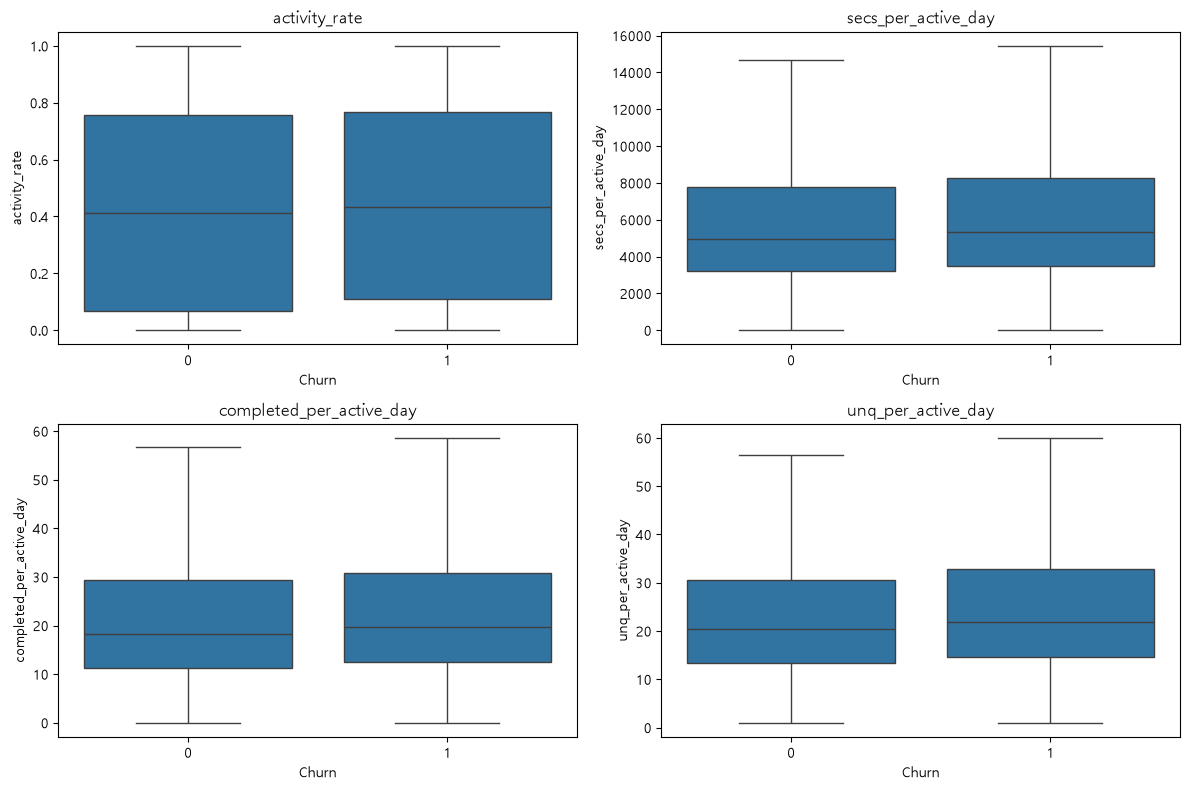

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, feature_cols):

    sns.boxplot(
        data=train,
        x=target,
        y=col,
        ax=ax,
        showfliers=False
    )

    ax.set_title(col)
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.show()

In [70]:
display(
    train.groupby(target)["days_since_last_log"]
    .agg(["mean", "median", "max"])
)

,mean,median,max
is_churn,,,
0,4.408167,0.0,89.0
1,4.039948,0.0,89.0


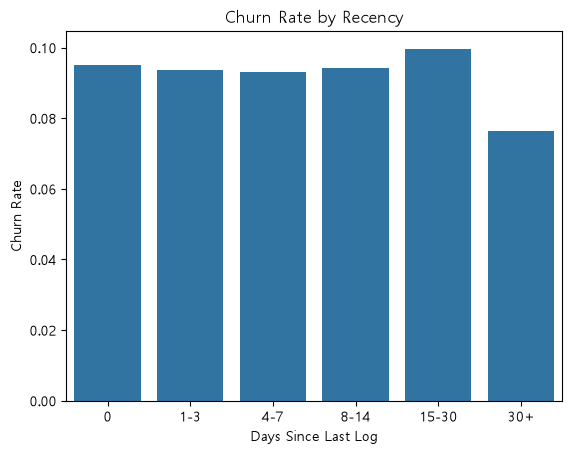

In [71]:
# Recency Groups
train["recency_group"] = pd.cut(
    train["days_since_last_log"],
    bins=[-1, 0, 3, 7, 14, 30, np.inf],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "30+"]
)

recency_churn = (
    train.groupby("recency_group", observed=True)[target]
    .mean()
    .reset_index()
)

sns.barplot(data=recency_churn, x="recency_group", y=target)

plt.title("Churn Rate by Recency")
plt.xlabel("Days Since Last Log")
plt.ylabel("Churn Rate")
plt.show()

In [72]:
display(
    train.groupby("recency_group", observed=True)[target]
    .agg(
        customers="count",
        churn_rate="mean"
    )
)

,customers,churn_rate
recency_group,,
0,36141,0.094989
1-3,15297,0.093548
4-7,5463,0.092989
8-14,3109,0.094243
15-30,2578,0.099690
30+,2761,0.076422


## Additional Features

In [73]:
for frame in (train, valid):

    # H1. 최근 7일간 미이용 고객
    frame["inactive_7days"] = (
        frame["days_since_last_log"].gt(7) |
        frame["has_log"].eq(0)
    ).astype(int)

    # H2. 청취시간 1시간당 완청 곡 수
    listening_hours = frame["total_secs"].replace(0, np.nan) / 3600

    frame["completed_per_hour"] = (
        frame["total_num_100"] / listening_hours
    )

    # H3. 과거 거래 취소 비율
    tx_count = frame["transaction_count"].replace(0, np.nan)

    frame["cancel_rate"] = (
        frame["cancel_count"] / tx_count
    )

    # H4. 자동 갱신 미사용 + 낮은 활동량
    frame["no_auto_renew_low_activity"] = (
        frame["last_auto_renew"].eq(0) &
        frame["activity_days"].le(5)
    ).astype(int)

    # H5. 장기 가입 + 낮은 활동량
    registration = pd.to_datetime(
        frame["registration_init_time"].astype("Int64").astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    frame["tenure_days"] = (
        pd.Timestamp("2017-02-28") - registration
    ).dt.days

    frame["long_tenure_low_activity"] = (
        frame["tenure_days"].ge(365) &
        frame["activity_days"].le(5)
    ).astype(int)

In [74]:
feature_cols = [
    "inactive_7days",
    "completed_per_hour",
    "cancel_rate",
    "no_auto_renew_low_activity",
    "long_tenure_low_activity"
]

display(
    train.groupby(target)[feature_cols]
    .mean()
    .T
    .round(4)
)

is_churn,0,1
inactive_7days,0.2926,0.2498
completed_per_hour,13.0219,13.0727
cancel_rate,0.0131,0.0228
no_auto_renew_low_activity,0.0021,0.0528
long_tenure_low_activity,0.0942,0.1128


In [75]:
binary_features = [
    "inactive_7days",
    "no_auto_renew_low_activity",
    "long_tenure_low_activity"
]

for col in binary_features:
    print(f"\n[{col}]")

    display(
        train.groupby(col)[target]
        .agg(
            customers="count",
            churn_rate="mean"
        )
        .round(4)
    )


[inactive_7days]


,customers,churn_rate
inactive_7days,,
0,56901,0.0944
1,23099,0.0774



[no_auto_renew_low_activity]


,customers,churn_rate
no_auto_renew_low_activity,,
0,79467,0.0854
1,533,0.7092



[long_tenure_low_activity]


,customers,churn_rate
long_tenure_low_activity,,
0,72333,0.0878
1,7667,0.1054


# Data Preprocessing

In [76]:
# 1. 로그 결측치 처리

for frame in (train, valid):

    frame["days_since_last_log"] = (
        frame["days_since_last_log"].fillna(90)
    )

    # 무한대 처리
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

In [77]:
# 2. Features / Target Split

excluded = [
    "msno",
    "registration_init_time",
    "bd",
    "days_to_expire",  # 데이터 누수(정답 유출) → 제외
    "recency_group"  # EDA용 컬럼 제외
]

x_train = train.drop(
    columns=[target] + excluded,
    errors="ignore"
).copy()

x_valid = valid.drop(
    columns=[target] + excluded,
    errors="ignore"
).copy()

y_train = train[target].astype(int)
y_valid = valid[target].astype(int)

In [78]:
# 3. Feature Types

cat_cols = [
    "city",
    "gender",
    "registered_via"
]

cat_cols = [
    col for col in cat_cols
    if col in x_train.columns
]

num_cols = [
    col for col in x_train.columns
    if col not in cat_cols
]

assert "days_to_expire" not in num_cols, "누수 피처 days_to_expire가 포함되어 있음"

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['city', 'gender', 'registered_via']
Numerical: ['transaction_count', 'cancel_count', 'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days', 'cancel_on_last_date', 'activity_days', 'total_secs', 'total_num_100', 'total_num_unq', 'days_since_last_log', 'has_transaction', 'has_log', 'activity_rate', 'secs_per_active_day', 'completed_per_active_day', 'unq_per_active_day', 'inactive_7days', 'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity', 'tenure_days', 'long_tenure_low_activity']


In [79]:
# 4. Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# 수치형
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        keep_empty_features=True
    )),
    ("scaler", StandardScaler())
])

# 범주형
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="unknown"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# 데이터 타입 정리
for frame in (x_train, x_valid):

    for col in num_cols:
        frame[col] = pd.to_numeric(
            frame[col], errors="coerce"
        )

    for col in cat_cols:
        frame[col] = (
            frame[col]
            .astype("string")
            .fillna("unknown")
            .astype(str)
        )

# 통합 전처리
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 학습 데이터 기준
x_train_ready = preprocess.fit_transform(x_train)

# 검증 데이터에는 transform만 적용
x_valid_ready = preprocess.transform(x_valid)

print("Train:", x_train_ready.shape)
print("Valid:", x_valid_ready.shape)

Train: (80000, 55)
Valid: (20000, 55)


In [80]:
# 5. Validation

print("Train NaN:", np.isnan(x_train_ready).sum())
print("Valid NaN:", np.isnan(x_valid_ready).sum())

print("Train Inf:", np.isinf(x_train_ready).sum())
print("Valid Inf:", np.isinf(x_valid_ready).sum())

print("Feature Count:", x_train_ready.shape[1])

Train NaN: 0
Valid NaN: 0
Train Inf: 0
Valid Inf: 0
Feature Count: 55


# Modeling

In [81]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

DROPOUT = 0.5   # Result 요약에 자동 반영됨

X = np.asarray(x_train_ready, dtype=np.float32)
X_valid = np.asarray(x_valid_ready, dtype=np.float32)
y = y_train.to_numpy(dtype=np.float32)

# EarlyStopping에 쓸 데이터는 train 안에서 분리
X_fit, X_stop, y_fit, y_stop = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

loader = DataLoader(
    TensorDataset(torch.from_numpy(X_fit), torch.from_numpy(y_fit)),
    batch_size=256,
    shuffle=True
)

X_stop_t = torch.from_numpy(X_stop).to(device)
y_stop_t = torch.from_numpy(y_stop).to(device)

# Dropout 추가
model = nn.Sequential(
    nn.Linear(X.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(32, 1)
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

best_loss = float("inf")
best_weights = None
best_epoch = 0
wait = 0
patience = 8

for epoch in range(100):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb).squeeze(1)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        stop_logits = model(X_stop_t).squeeze(1)
        stop_loss = loss_fn(stop_logits, y_stop_t).item()

    print(f"Epoch {epoch + 1:3d} | val_loss: {stop_loss:.4f}")

    if stop_loss < best_loss:
        best_loss = stop_loss
        best_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("EarlyStopping")
            break

last_epoch = epoch + 1
model.load_state_dict(best_weights)

# 원래 valid 데이터로 최종 평가
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_valid).to(device)).squeeze(1)
    proba = torch.sigmoid(logits).cpu().numpy()

pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_valid, proba), 4))
print("PR-AUC:", round(average_precision_score(y_valid, proba), 4))
print("F1@0.5:", round(f1_score(y_valid, pred), 4))

Epoch   1 | val_loss: 0.2164
Epoch   2 | val_loss: 0.2086
Epoch   3 | val_loss: 0.2075
Epoch   4 | val_loss: 0.2082
Epoch   5 | val_loss: 0.2073
Epoch   6 | val_loss: 0.2066
Epoch   7 | val_loss: 0.2065
Epoch   8 | val_loss: 0.2059
Epoch   9 | val_loss: 0.2056
Epoch  10 | val_loss: 0.2052
Epoch  11 | val_loss: 0.2056
Epoch  12 | val_loss: 0.2060
Epoch  13 | val_loss: 0.2046
Epoch  14 | val_loss: 0.2043
Epoch  15 | val_loss: 0.2041
Epoch  16 | val_loss: 0.2046
Epoch  17 | val_loss: 0.2039
Epoch  18 | val_loss: 0.2038
Epoch  19 | val_loss: 0.2035
Epoch  20 | val_loss: 0.2035
Epoch  21 | val_loss: 0.2035
Epoch  22 | val_loss: 0.2031
Epoch  23 | val_loss: 0.2030
Epoch  24 | val_loss: 0.2029
Epoch  25 | val_loss: 0.2028
Epoch  26 | val_loss: 0.2026
Epoch  27 | val_loss: 0.2027
Epoch  28 | val_loss: 0.2025
Epoch  29 | val_loss: 0.2026
Epoch  30 | val_loss: 0.2023
Epoch  31 | val_loss: 0.2023
Epoch  32 | val_loss: 0.2022
Epoch  33 | val_loss: 0.2023
Epoch  34 | val_loss: 0.2022
Epoch  35 | va

## ROC Curve

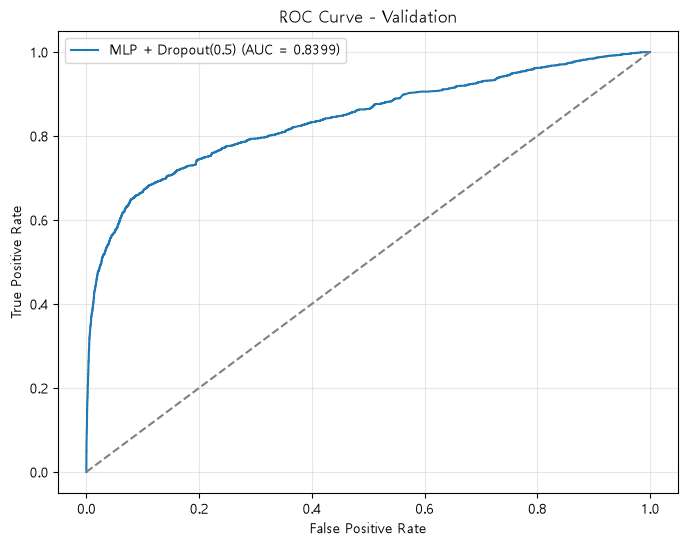

In [82]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_valid, proba)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    label=f"MLP + Dropout({DROPOUT}) (AUC = {roc_auc_score(y_valid, proba):.4f})"
)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Result

In [83]:
# 학습·평가 결과 요약 (실행할 때마다 자동으로 갱신됨)
result = pd.Series({
    "Dropout": DROPOUT,
    "학습 종료 epoch": last_epoch,
    "최저 검증 손실 epoch": best_epoch,
    "최저 검증 손실": round(best_loss, 4),
    "ROC-AUC": round(roc_auc_score(y_valid, proba), 4),
    "PR-AUC": round(average_precision_score(y_valid, proba), 4),
    "F1-score (기준값 0.5)": round(f1_score(y_valid, pred), 4),
}, name="값")
display(result.to_frame())

,값
Dropout,0.5000
학습 종료 epoch,45.0000
최저 검증 손실 epoch,37.0000
최저 검증 손실,0.2017
ROC-AUC,0.8399
PR-AUC,0.5805
F1-score (기준값 0.5),0.5119


### 3. Dropout MLP — Result Snapshot
최종 비교를 위해 이 모델의 평가 결과를 고유 변수에 저장합니다.


In [84]:
# 모델 3 결과 저장
# 원본 노트북의 평가 변수(y_valid, proba, pred)를 그대로 사용
from sklearn.metrics import recall_score, f1_score, roc_auc_score

dropout_result = {
    "Model": "Dropout MLP + EarlyStopping",
    "Owner": "Sohee",
    "Evaluation Set": "Validation",
    "AUC": float(roc_auc_score(y_valid, proba)),
    "Recall": float(recall_score(y_valid, pred)),
    "F1": float(f1_score(y_valid, pred))
}
display(pd.DataFrame([dropout_result]).round(4))


,Model,Owner,Evaluation Set,AUC,Recall,F1
0,Dropout MLP + EarlyStopping,Sohee,Validation,0.8399,0.3777,0.5119



---
# 4. BatchNorm + Dropout MLP
**BatchNorm + Dropout + EarlyStopping · Yongwoo**

아래 코드는 해당 팀원의 원본 노트북 흐름을 유지합니다.



# 1. Members feature engineering

## integrated_data 불러오기 및 기준일 설정

In [85]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")


In [86]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

### 클래스 비율 확인

In [87]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


### member 관련 feature 엔지니어링

#### 멤버정보가 없는 멤버 관련 피쳐 생성

In [88]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

#### registration_init_time

In [89]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [90]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수


In [91]:

df_all['reg_year'] = reg.dt.year                            # 가입 연도




season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

#### gender

In [92]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

#### bd

In [93]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [94]:
df_all["bd_bin"] = pd.cut( # 피쳐로 사용은 나중에
    df_all['bd_clean'],
    bins=[10, 20, 30, 40, 50, 60, np.inf],  # 60세 이상 전체를 포함하도록 np.inf 활용
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,  # 이상 ~ 미만 설정
)

#### city

In [95]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [96]:
# 1. city 값별 사용자 수 및 비중 확인
city_summary = df_all.groupby('city').agg(
    cnt=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

city_summary['ratio'] = (city_summary['cnt'] / len(df_all) * 100).round(2)
print(city_summary.sort_values(by='cnt', ascending=False).head(10))

# 2. city가 1 인 유저들이 성별(gender)이나 나이(bd)도 미입력(NaN/0)인 경우가 많은지 교차 확인
print(df_all[df_all['city'] == 1]['gender_status'].value_counts(normalize=True))
print(df_all[df_all['city'] == 1]['bd_isnan'].value_counts(normalize=True)) 
# city가 1인데 성별 미입력 96퍼, 나이 미입력 97퍼

    city    cnt  churn_rate  ratio
0    1.0  45747    0.063982  45.75
11  13.0   9914    0.122655   9.91
3    5.0   7281    0.130889   7.28
2    4.0   4756    0.137931   4.76
13  15.0   4524    0.125553   4.52
20  22.0   4252    0.120179   4.25
4    6.0   2621    0.141167   2.62
12  14.0   2028    0.114892   2.03
10  12.0   1159    0.121657   1.16
7    9.0    992    0.122984   0.99
gender_status
미입력       0.968370
female    0.016416
male      0.015214
Name: proportion, dtype: float64
bd_isnan
1    0.974031
0    0.025969
Name: proportion, dtype: float64


#### member데이터아닌 다른 데이터 피쳐 엔지니어링

In [97]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [98]:
# 교차에 쓸 그룹 컬럼 (그래프용, 모델에는 안 넣음)
df_all['tenure_grp'] = pd.cut(df_all['tenure_date'],
                               bins=[-1, 365, 730, 1825, np.inf],
                               labels=['1년 미만', '1~2년', '2~5년', '5년 이상'])
df_all['age_grp'] = pd.cut(df_all['bd_clean'], bins=[9, 19, 29, 39, 80],
                            labels=['10대', '20대', '30대', '40대+'])

def age_log_diff(df, col):
    has_log = df['has_log'] == 1
    med = df[has_log].groupby('age_grp', observed=True)[col].median()   # 연령대별 중앙값
    diff = df[col] - df['age_grp'].map(med).astype(float)             # 내 값 - 내 연령대 중앙값
    return diff.where(has_log)                                         # 로그 없는 사람은 NaN

df_all['age_activity_diff'] = age_log_diff(df_all, 'activity_days')
df_all['age_secs_diff']     = age_log_diff(df_all, 'total_secs')


In [99]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff'],
      dtype='object')

In [100]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    'reg_season',
]

numbers = [
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',
    
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',
    
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',
    
    'trans_per_year', 'pay_per_year',
]

all_col = categories + numbers

### 피처 합치기

In [101]:

# H1. 최근 7일간 미이용 고객
df_all["inactive_7days"] = (
df_all["days_since_last_log"].gt(7) |
df_all["has_log"].eq(0)
).astype(int)

# H2. 청취시간 1시간당 완청 곡 수
listening_hours = df_all["total_secs"].replace(0, np.nan) / 3600

df_all["completed_per_hour"] = (
df_all["total_num_100"] / listening_hours
)

# H3. 과거 거래 취소 비율
tx_count = df_all["transaction_count"].replace(0, np.nan)

df_all["cancel_rate"] = (
df_all["cancel_count"] / tx_count
)

# H4. 자동 갱신 미사용 + 낮은 활동량
df_all["no_auto_renew_low_activity"] = (
    df_all["last_auto_renew"].eq(0) &
    df_all["activity_days"].le(5)
).astype(int)

# H5. 장기 가입 + 낮은 활동량
df_all["long_tenure_low_activity"] = (
    df_all["tenure_date"].ge(365) &
    df_all["activity_days"].le(5)
).astype(int)

In [102]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


df_all = add_features(df_all)


In [103]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff', 'inactive_7days',
       'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity',
       'long_tenure_low_activity', 'no_unique_song', 'zero_plan_days',
       'avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
       'complete_per_unq', 'payment_pe

In [104]:
base_members = ['registered_via', 'city_clean', 'gender_status']
team_base = ['transaction_count', 'cancel_count', 'total_payment',
             'last_auto_renew', 'last_is_cancel', 'last_plan_days',
             'cancel_on_last_date', 'has_transaction',          # days_to_expire 제외
             'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
             'days_since_last_log', 'has_log']

mine  = ['reg_season', 'has_member', 'tenure_date', 'same_join_day', 'bd_clean',
         'bd_isnan', 'age_at_reg', 'city_miss', 'trans_per_year', 'pay_per_year']
sohee = ['inactive_7days', 'completed_per_hour', 'cancel_rate',
         'no_auto_renew_low_activity', 'long_tenure_low_activity']
sunah = ['avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
         'complete_per_unq', 'payment_per_plan_day', 'no_unique_song', 'zero_plan_days']

feature_sets = {
    '① 기본':        base_members + team_base,
    '② 기본 + 본인': base_members + team_base + mine,
    '③ 기본 + 소희': base_members + team_base + sohee,
    '④ 기본 + 선아': base_members + team_base + sunah,
    '⑤ 전체':        base_members + team_base + mine + sohee + sunah,
}

In [105]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    #'reg_season',
]

numbers = [
    # members (본인)
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',

    # 거래 (팀 통합)
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',

    # 로그 (팀 통합)
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',

    #members 결합 (본인)
    'trans_per_year', #'pay_per_year',

     # 소희
     #'inactive_7days', 'completed_per_hour', 'cancel_rate',
     #'no_auto_renew_low_activity', 'long_tenure_low_activity',

    # # 선아
    'avg_payment', 
    'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
    'complete_per_unq', 'payment_per_plan_day',
    'no_unique_song', 'zero_plan_days',
]

all_col = categories + numbers   # 4 + 36 = 40개

In [106]:
from sklearn.model_selection import train_test_split

df_all[categories] = df_all[categories].astype('category')

all_col = categories+numbers

feature = df_all[all_col]
target = df_all[targets]

x_train, x_test, y_train, y_test = train_test_split(feature, target, random_state=args.seed,test_size=0.2, stratify=args.target)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((80000, 33), (80000,), (20000, 33), (20000,))

In [107]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate

In [108]:
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2, stratify=y_train, random_state=args.seed
)

x_tr.shape, x_val.shape, y_tr.mean(), y_val.mean()

((64000, 33), (16000, 33), np.float64(0.089515625), np.float64(0.0895))

In [109]:
x_tr[numbers].describe().T

,count,mean,std,min,25%,50%,75%,max
has_member,64000.0,0.886750,0.316901,0.000000,1.000000,1.000000,1.000000,1.000000e+00
tenure_date,56752.0,1270.174901,1099.879178,0.000000,409.000000,1015.000000,1846.000000,4.722000e+03
same_join_day,56752.0,40.067892,27.698540,1.000000,19.000000,34.000000,58.000000,1.720000e+02
bd_clean,25292.0,29.873596,8.815384,12.000000,24.000000,28.000000,34.000000,8.000000e+01
bd_isnan,64000.0,0.604812,0.488895,0.000000,0.000000,1.000000,1.000000,1.000000e+00
age_at_reg,25292.0,24.880575,8.504791,4.991781,18.931507,23.016438,28.841096,7.947397e+01
city_miss,64000.0,0.458750,0.498299,0.000000,0.000000,0.000000,1.000000,1.000000e+00
transaction_count,64000.0,15.787453,8.691633,0.000000,8.000000,16.000000,23.000000,5.900000e+01
cancel_count,64000.0,0.259766,0.565253,0.000000,0.000000,0.000000,0.000000,1.000000e+01
total_payment,64000.0,2128.605859,1259.421296,0.000000,1043.000000,1881.000000,3278.000000,7.450000e+03


In [110]:
log_cols = [
    "payment_per_plan_day", "complete_per_unq", "total_num_100", "avg_daily_complete",
    "days_since_last_log", "total_secs", "total_num_unq", "last_plan_days",
    "avg_daily_unq", "avg_payment", "avg_daily_secs", "trans_per_year",
]
rest_cols = [c for c in numbers if c not in log_cols]

In [111]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

log_pipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler()),
])
num_pipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("log", log_pipe, log_cols),
    ("num", num_pipe, rest_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categories),
])

In [112]:
X_tr  = preprocess.fit_transform(x_tr).astype("float32")
X_val = preprocess.transform(x_val).astype("float32")
X_te  = preprocess.transform(x_test).astype("float32")

X_tr.shape, X_val.shape, X_te.shape

((64000, 58), (16000, 58), (20000, 58))

In [113]:
np.isnan(X_tr).sum(), np.isnan(X_te).sum()

(np.int64(0), np.int64(0))

In [114]:
import torch
print(torch.__version__)

2.14.0+cpu


In [115]:
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(args.seed)
device = "cuda" if torch.cuda.is_available() else "cpu"

y_tr_np  = y_tr.to_numpy().ravel().astype("float32")
y_val_np = y_val.to_numpy().ravel().astype("float32")
y_te_np  = y_test.to_numpy().ravel().astype("float32")

train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_np))
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True)

In [116]:
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),      nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr.shape[1]).to(device)
model

MLP(
  (net): Sequential(
    (0): Linear(in_features=58, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [117]:
model.eval()
with torch.no_grad():
    out = model(torch.tensor(X_tr[:5]).to(device))
out.shape

torch.Size([5])

In [118]:
import copy
from sklearn.metrics import roc_auc_score

pos_weight = torch.tensor((y_tr_np == 0).sum() / (y_tr_np == 1).sum(), device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [119]:
X_val_t = torch.tensor(X_val).to(device)

epochs = 200
patience = 10
best_auc, best_state, wait = 0, None, 0
history = []

for epoch in range(1, epochs + 1):
    # 학습
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # 검증
    model.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy()
    val_auc = roc_auc_score(y_val_np, val_prob)
    history.append((epoch, np.mean(batch_losses), val_auc))
    print(f"{epoch:3d} | loss {np.mean(batch_losses):.4f} | val ROC-AUC {val_auc:.4f}")

    # EarlyStopping
    if val_auc > best_auc:
        best_auc, wait = val_auc, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= patience:
            print(f"조기 종료: {epoch}에폭 / 최고 검증 ROC-AUC {best_auc:.4f}")
            break

model.load_state_dict(best_state)

  1 | loss 0.9360 | val ROC-AUC 0.8400
  2 | loss 0.8707 | val ROC-AUC 0.8456
  3 | loss 0.8645 | val ROC-AUC 0.8480
  4 | loss 0.8619 | val ROC-AUC 0.8492
  5 | loss 0.8543 | val ROC-AUC 0.8503
  6 | loss 0.8502 | val ROC-AUC 0.8500
  7 | loss 0.8478 | val ROC-AUC 0.8499
  8 | loss 0.8429 | val ROC-AUC 0.8531
  9 | loss 0.8421 | val ROC-AUC 0.8516
 10 | loss 0.8417 | val ROC-AUC 0.8541
 11 | loss 0.8411 | val ROC-AUC 0.8556
 12 | loss 0.8374 | val ROC-AUC 0.8536
 13 | loss 0.8334 | val ROC-AUC 0.8524
 14 | loss 0.8335 | val ROC-AUC 0.8548
 15 | loss 0.8279 | val ROC-AUC 0.8535
 16 | loss 0.8330 | val ROC-AUC 0.8552
 17 | loss 0.8310 | val ROC-AUC 0.8535
 18 | loss 0.8278 | val ROC-AUC 0.8561
 19 | loss 0.8293 | val ROC-AUC 0.8551
 20 | loss 0.8241 | val ROC-AUC 0.8541
 21 | loss 0.8217 | val ROC-AUC 0.8561
 22 | loss 0.8248 | val ROC-AUC 0.8557
 23 | loss 0.8184 | val ROC-AUC 0.8552
 24 | loss 0.8198 | val ROC-AUC 0.8570
 25 | loss 0.8222 | val ROC-AUC 0.8554
 26 | loss 0.8203 | val R

<All keys matched successfully>

In [120]:
from sklearn.metrics import average_precision_score

X_te_t = torch.tensor(X_te).to(device)

model.eval()
with torch.no_grad():
    te_prob  = torch.sigmoid(model(X_te_t)).cpu().numpy()
    val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy()

dl_roc = roc_auc_score(y_te_np, te_prob)
dl_pr  = average_precision_score(y_te_np, te_prob)
print(f"테스트 ROC-AUC: {dl_roc:.4f} | PR-AUC: {dl_pr:.4f}")

테스트 ROC-AUC: 0.8485 | PR-AUC: 0.5855


In [121]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val_np, val_prob)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1[:-1].argmax()
TH_DL = thresholds[best_idx]
print(f"기준선 {TH_DL:.3f} | 검증 재현율 {recall[best_idx]:.3f} | 검증 정밀도 {precision[best_idx]:.3f}")

기준선 0.755 | 검증 재현율 0.557 | 검증 정밀도 0.574


In [122]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

te_pred = (te_prob >= TH_DL).astype(int)
dl_rec  = recall_score(y_te_np, te_pred)
dl_prec = precision_score(y_te_np, te_pred)

print(confusion_matrix(y_te_np, te_pred))

compare = pd.DataFrame({
    "LightGBM(튜닝)": [0.8717, 0.6065, 0.280, 0.53, 0.64],
    "MLP(BN+Dropout+ES)": [dl_roc, dl_pr, TH_DL, dl_rec, dl_prec],
}, index=["ROC-AUC", "PR-AUC", "기준선", "재현율", "정밀도"]).round(4)
compare

[[17475   735]
 [  799   991]]


,LightGBM(튜닝),MLP(BN+Dropout+ES)
ROC-AUC,0.8717,0.8485
PR-AUC,0.6065,0.5855
기준선,0.2800,0.7548
재현율,0.5300,0.5536
정밀도,0.6400,0.5742


In [123]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

y_train_np = y_train.to_numpy().ravel()

lgb_params = dict(
    n_estimators=100, learning_rate=0.0302, num_leaves=31,
    min_child_samples=76, random_state=args.seed, verbosity=-1,
)

# 기준선: 학습 데이터 교차 검증 예측으로
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args.seed)
cv_prob = cross_val_predict(
    LGBMClassifier(**lgb_params), x_train, y_train_np, cv=skf, method="predict_proba"
)[:, 1]

p, r, t = precision_recall_curve(y_train_np, cv_prob)
f1_lgb = 2 * p * r / (p + r + 1e-9)
TH_LGB = t[f1_lgb[:-1].argmax()]

# 최종 학습 + 테스트 예측
lgb = LGBMClassifier(**lgb_params).fit(x_train, y_train_np)
lgb_prob = lgb.predict_proba(x_test)[:, 1]
lgb_pred = (lgb_prob >= TH_LGB).astype(int)

print(f"LightGBM 기준선 {TH_LGB:.3f}")

LightGBM 기준선 0.279


In [124]:
def summary(y, prob, th):
    pred = (prob >= th).astype(int)
    return [roc_auc_score(y, prob), average_precision_score(y, prob), th,
            recall_score(y, pred), precision_score(y, pred)]

compare = pd.DataFrame({
    "LightGBM(튜닝)":     summary(y_te_np, lgb_prob, TH_LGB),
    "MLP(BN+Dropout+ES)": summary(y_te_np, te_prob,  TH_DL),
}, index=["ROC-AUC", "PR-AUC", "기준선", "재현율", "정밀도"]).round(4)
compare

,LightGBM(튜닝),MLP(BN+Dropout+ES)
ROC-AUC,0.8717,0.8485
PR-AUC,0.6065,0.5855
기준선,0.2791,0.7548
재현율,0.5313,0.5536
정밀도,0.6344,0.5742


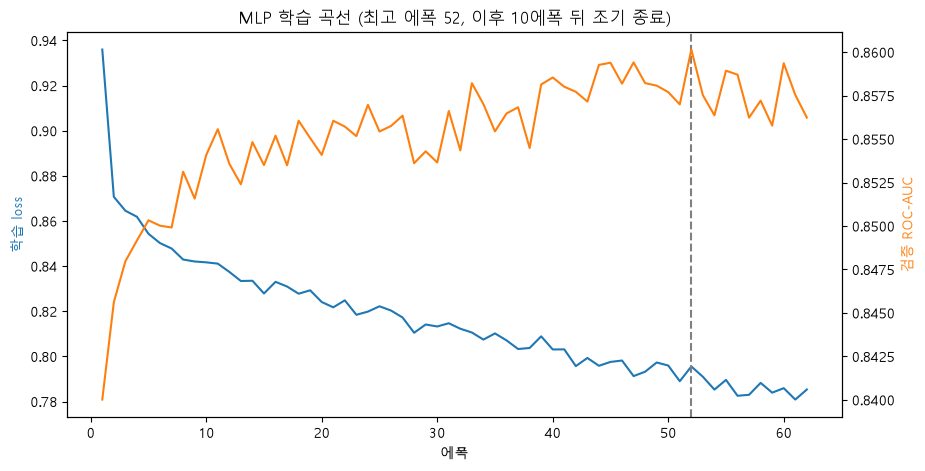

In [125]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(history, columns=["epoch", "loss", "val_auc"])
best_epoch = hist.loc[hist["val_auc"].idxmax(), "epoch"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(hist["epoch"], hist["loss"], color="tab:blue", label="학습 loss")
ax1.set_xlabel("에폭")
ax1.set_ylabel("학습 loss", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(hist["epoch"], hist["val_auc"], color="tab:orange", label="검증 ROC-AUC")
ax2.set_ylabel("검증 ROC-AUC", color="tab:orange")

ax1.axvline(best_epoch, color="gray", linestyle="--")
ax1.set_title(f"MLP 학습 곡선 (최고 에폭 {best_epoch}, 이후 10에폭 뒤 조기 종료)")
plt.show()

### 4. BatchNorm + Dropout MLP — Result Snapshot
최종 비교를 위해 이 모델의 평가 결과를 고유 변수에 저장합니다.


In [126]:
# 모델 4 결과 저장
from sklearn.metrics import f1_score

combined_result = {
    "Model": "BatchNorm + Dropout MLP + EarlyStopping",
    "Owner": "Yongwoo",
    "Evaluation Set": "Test",
    "AUC": float(dl_roc),
    "Recall": float(dl_rec),
    "F1": float(f1_score(y_te_np, te_pred))
}
display(pd.DataFrame([combined_result]).round(4))


,Model,Owner,Evaluation Set,AUC,Recall,F1
0,BatchNorm + Dropout MLP + EarlyStopping,Yongwoo,Test,0.8485,0.5536,0.5637



---
# 5. Final Model Comparison

네 모델의 결과를 한 표로 모으고 **AUC가 가장 높은 모델을 최고 모델로 선정**합니다.

> 참고: 모델들은 독립적으로 구성되었으므로 전처리·학습 설정이 동일하지 않을 수 있습니다. 또한 원본 코드상 Dropout 모델은 `Validation`, 나머지 모델은 `Test` 평가값을 사용합니다.


In [127]:
# 4개 모델 결과 통합
model_comparison = pd.DataFrame([
    baseline_result,
    batchnorm_result,
    dropout_result,
    combined_result
])

# AUC 높은 순으로 정렬
model_comparison = model_comparison.sort_values(
    by="AUC", ascending=False
).reset_index(drop=True)

display(model_comparison.round(4))


,Model,Owner,Evaluation Set,AUC,Recall,F1
0,BatchNorm + Dropout MLP + EarlyStopping,Yongwoo,Test,0.8485,0.5536,0.5637
1,BatchNorm MLP + EarlyStopping,Sunah,Test,0.8458,0.3849,0.5157
2,Dropout MLP + EarlyStopping,Sohee,Validation,0.8399,0.3777,0.5119
3,Baseline MLP + EarlyStopping,Heeyoung,Test,0.8338,0.6592,0.5087


In [128]:
# AUC 기준 최고 모델 선정
best_idx = model_comparison["AUC"].idxmax()
best_model = model_comparison.loc[best_idx]

print("=" * 60)
print("🏆 BEST MODEL — AUC 기준")
print("=" * 60)
print(f"Model          : {best_model['Model']}")
print(f"Owner          : {best_model['Owner']}")
print(f"Evaluation Set : {best_model['Evaluation Set']}")
print(f"AUC            : {best_model['AUC']:.4f}")
print(f"Recall         : {best_model['Recall']:.4f}")
print(f"F1             : {best_model['F1']:.4f}")
print("=" * 60)


🏆 BEST MODEL — AUC 기준
Model          : BatchNorm + Dropout MLP + EarlyStopping
Owner          : Yongwoo
Evaluation Set : Test
AUC            : 0.8485
Recall         : 0.5536
F1             : 0.5637


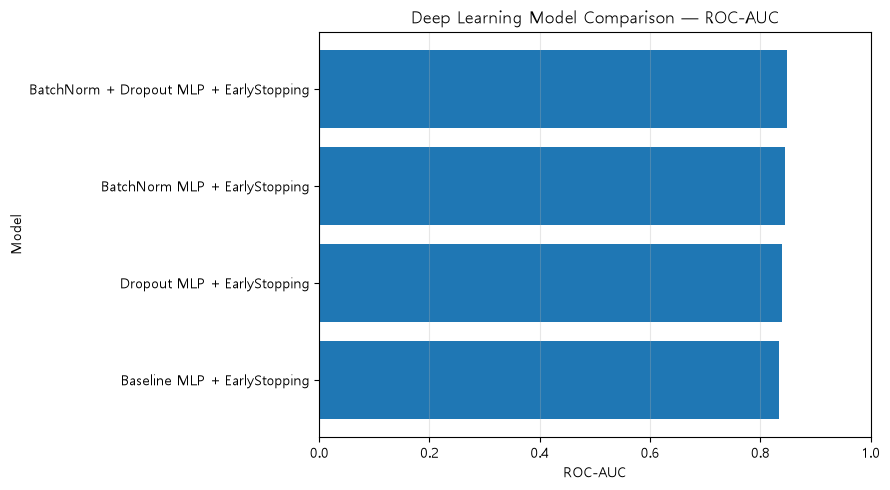

In [129]:
# AUC 비교 시각화
import matplotlib.pyplot as plt

plot_df = model_comparison.sort_values('AUC', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df['Model'], plot_df['AUC'])
plt.xlabel('ROC-AUC')
plt.ylabel('Model')
plt.title('Deep Learning Model Comparison — ROC-AUC')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
